In [16]:
import numpy as np
import scipy.stats as stats
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

When we see a data distribution, we can use it to put observations in context. Let's see how.  

Since we're going to be generating data, we'll start by setting a random seed for reproducibility.

In [17]:
rng = np.random.default_rng(2)

We're going to make some simulated data about people's heights. In most populations, height is normally distributed. The distribution of heights has varied over time- and by place- but we can look at one especially large dataset drawn from samples in Europe, North America, Australia, and East Asia ([you can read about it here](https://ourworldindata.org/human-height#height-is-normally-distributed)) 

In this dataset, for participants whose sex is female, the average height was 164.7 cm with a standard deviation of 7.07 cm.

In [18]:
height_mu = 164.7
height_sigma = 7.1
n_samples = 1000

# Generate the data from a normal distribution
data = stats.norm.rvs(loc=height_mu, 
                      scale=height_sigma, 
                      size=n_samples, 
                      random_state=rng)

# Create a dataframe with the data
df = pd.DataFrame({'height': data})

In [19]:
df.head()

,height
0,166.042279
1,160.988486
2,161.767249
3,147.365582
4,177.477922


## Visualize the data distribution

Text(0.5, 0, 'Height (cm)')

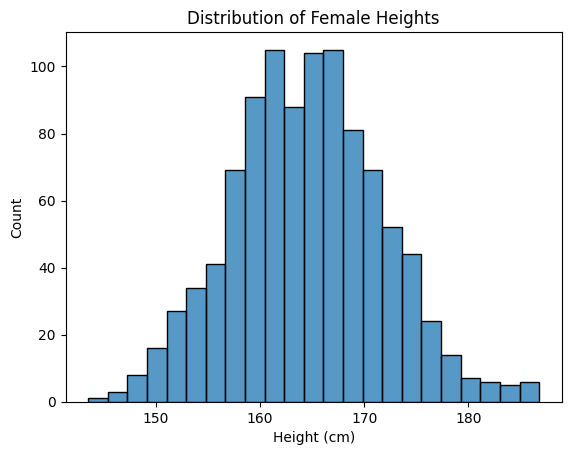

In [20]:
sns.histplot(data=df, x='height')
plt.title("Distribution of Female Heights")
plt.xlabel("Height (cm)")

## Thinking in percentiles
One way to think about individual observations in context of the whole distribution is to think about percentiles. For example: let's say we meet someone who is 172 cm tall. What percent of people in our sample would be shorter than 172 cm?  

In [ ]:
stats.percentileofscore(df.height, 172)

87.5

What if we met someone even taller- 180 cm? Now what percent of people in our sample are even shorter than them?

In [25]:
stats.percentileofscore(df.height, 180)

97.9

What if we met someone who is 150 cm tall? What percent of our sample is shorter than that?

In [26]:
stats.percentileofscore(df.height, 150)

1.8

## Thinking about the range of a distribution
Another way of reasoning about what observations might be surprising, versus typical, is to think about the _width_ of a distribution. There are a few ways to do this in numbers (we've already mentioned one, the standard deviation). 

First up: something called the _interquartile range_. This is defined as the difference between the upper and lower quartiles, $Q_1$ and $Q_3$. 

What's a quartile? Well, the lower quartile $Q_1$ is the value at the 25th percentile of our data distribution. The median, $Q_2$ is the value at the 50th percentile. What do you think the upper quartile is?  

In [34]:
q1 = stats.scoreatpercentile(df.height, 25)
q1

159.67506803536526

In [36]:
q3 = stats.scoreatpercentile(df.height, 75)
q3

169.34196728265724

In [37]:
iqr = q3 - q1
iqr

9.66689924729198

Luckily, we don't always have to do this by hand. There's a nice compact function in `scipy.stats`. 

In [38]:
stats.iqr(df.height)

9.666899247292008

Something nice about the IQR is that if we make a boxplot, by default, we'll see the quartiles, median, and IQR represented:

<Axes: xlabel='height'>

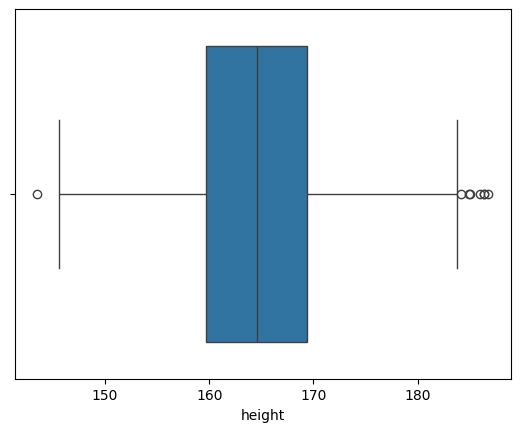

In [39]:
sns.boxplot(data=df, x='height')

We can generalize the idea of the interquartile range a bit. We don't have to have the endpoints at the 25th and 75th percentiles- we could place them anywhere. What if we wanted a range covering the middle 50% of our distribution, we wanted the middle 95%?

In [42]:
lower_bound_percentile = (100 - 95)/2
lower_bound_percentile

2.5

In [44]:
upper_bound_percentile = 100 - lower_bound_percentile
upper_bound_percentile

97.5

Now let's convert these bounds into heights- what height corresponds to the lower bound (the 2.5th percentile)?

In [45]:
height_at_lower_bound = stats.scoreatpercentile(df.height, lower_bound_percentile)
height_at_lower_bound

150.90064693718213

In [46]:
height_at_upper_bound = stats.scoreatpercentile(df.height, upper_bound_percentile)
height_at_upper_bound

178.25588511564274

We can mark these values on our visualization of the data distribution, which is often a helpful guide. 

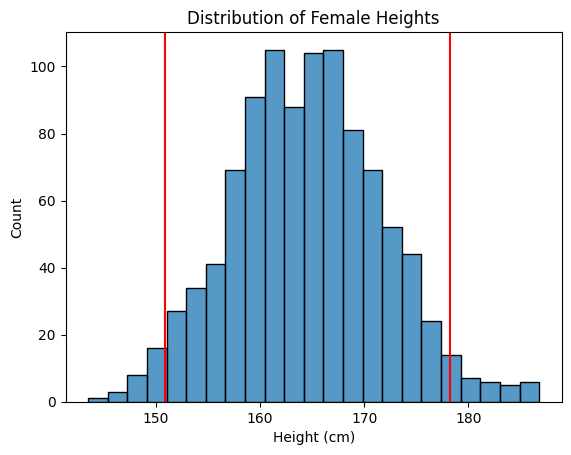

In [48]:
sns.histplot(data=df, x='height')
plt.title("Distribution of Female Heights")
plt.xlabel("Height (cm)")
plt.axvline(height_at_lower_bound, color='red')
plt.axvline(height_at_upper_bound, color='red')

This means 95% of our data falls in the range bounded by the vertical lines. 